EDA ANALYSIS:

In [71]:
# ==== EDA по bounding box'ам ====

import numpy as np
import pandas as pd
from pathlib import Path

# Если у тебя уже есть переменные dataset_path / labels_path, эта часть не нужна
# dataset_path = Path("dataset/train")
# labels_path = dataset_path / "labels"

bbox_rows = []

for lbl_path in labels_path.glob("*.txt"):
    with open(lbl_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls, x_c, y_c, w, h = parts
            cls = int(cls)
            x_c, y_c, w, h = map(float, (x_c, y_c, w, h))

            bbox_rows.append({
                "label_file": lbl_path.name,
                "class": cls,
                "x_center_rel": x_c,
                "y_center_rel": y_c,
                "w_rel": w,
                "h_rel": h,
                "area_rel": w * h,
                "aspect_ratio": w / h if h > 0 else np.nan
            })

df_bbox = pd.DataFrame(bbox_rows)
df_bbox.head()


,label_file,class,x_center_rel,y_center_rel,w_rel,h_rel,area_rel,aspect_ratio
0,-1-_jpg.rf.73cda585ea0ec05ad35eb72f1582638c.txt,6,0.460938,0.739844,0.098437,0.197656,0.019457,0.498024
1,-1-_jpg.rf.73cda585ea0ec05ad35eb72f1582638c.txt,2,0.882031,0.437500,0.235937,0.521875,0.123130,0.452096
2,-1-_jpg.rf.73cda585ea0ec05ad35eb72f1582638c.txt,2,0.166406,0.461719,0.332813,0.364063,0.121165,0.914163
3,-1-_jpg.rf.84ccc89e259f98afafa4b992d4fa09be.txt,6,0.554688,0.304688,0.443750,0.531250,0.235742,0.835294
4,-1-_jpg.rf.c56621cbbd864d2d6846dd4106449895.txt,6,0.484375,0.702344,0.359375,0.470313,0.169019,0.764120


In [72]:
# Общая статистика по размерам
df_bbox[["w_rel", "h_rel", "area_rel", "aspect_ratio"]].describe()


,w_rel,h_rel,area_rel,aspect_ratio
count,69619.000000,69619.000000,69619.000000,69619.000000
mean,0.113969,0.145950,0.048995,0.846948
std,0.173586,0.205328,0.148547,0.350210
min,0.001563,0.001563,0.000002,0.058824
25%,0.032813,0.040625,0.001214,0.608696
50%,0.050781,0.063281,0.003186,0.815574
75%,0.107813,0.128906,0.013193,1.029851
max,1.000000,1.000000,1.000000,10.000000


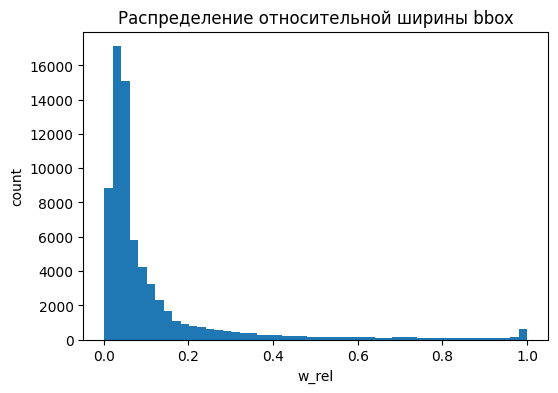

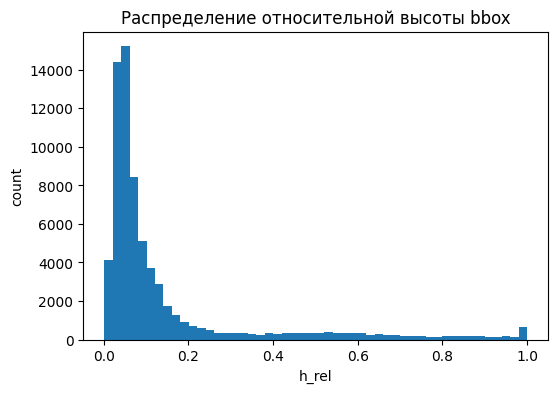

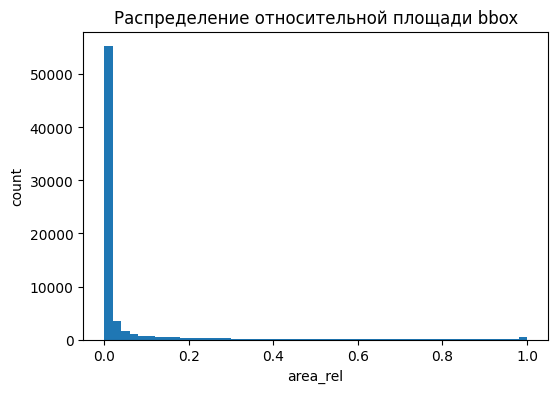

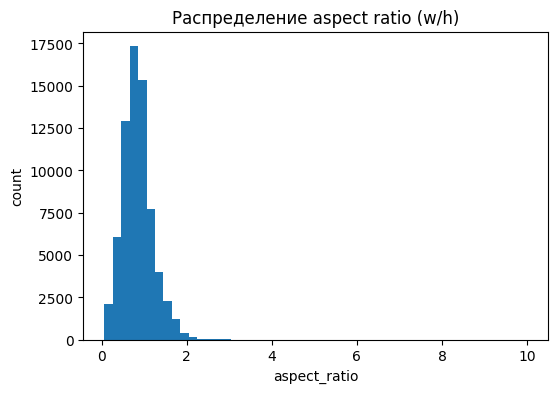

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df_bbox["w_rel"], bins=50)
plt.title("Распределение относительной ширины bbox")
plt.xlabel("w_rel")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df_bbox["h_rel"], bins=50)
plt.title("Распределение относительной высоты bbox")
plt.xlabel("h_rel")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df_bbox["area_rel"], bins=50)
plt.title("Распределение относительной площади bbox")
plt.xlabel("area_rel")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df_bbox["aspect_ratio"], bins=50)
plt.title("Распределение aspect ratio (w/h)")
plt.xlabel("aspect_ratio")
plt.ylabel("count")
plt.show()


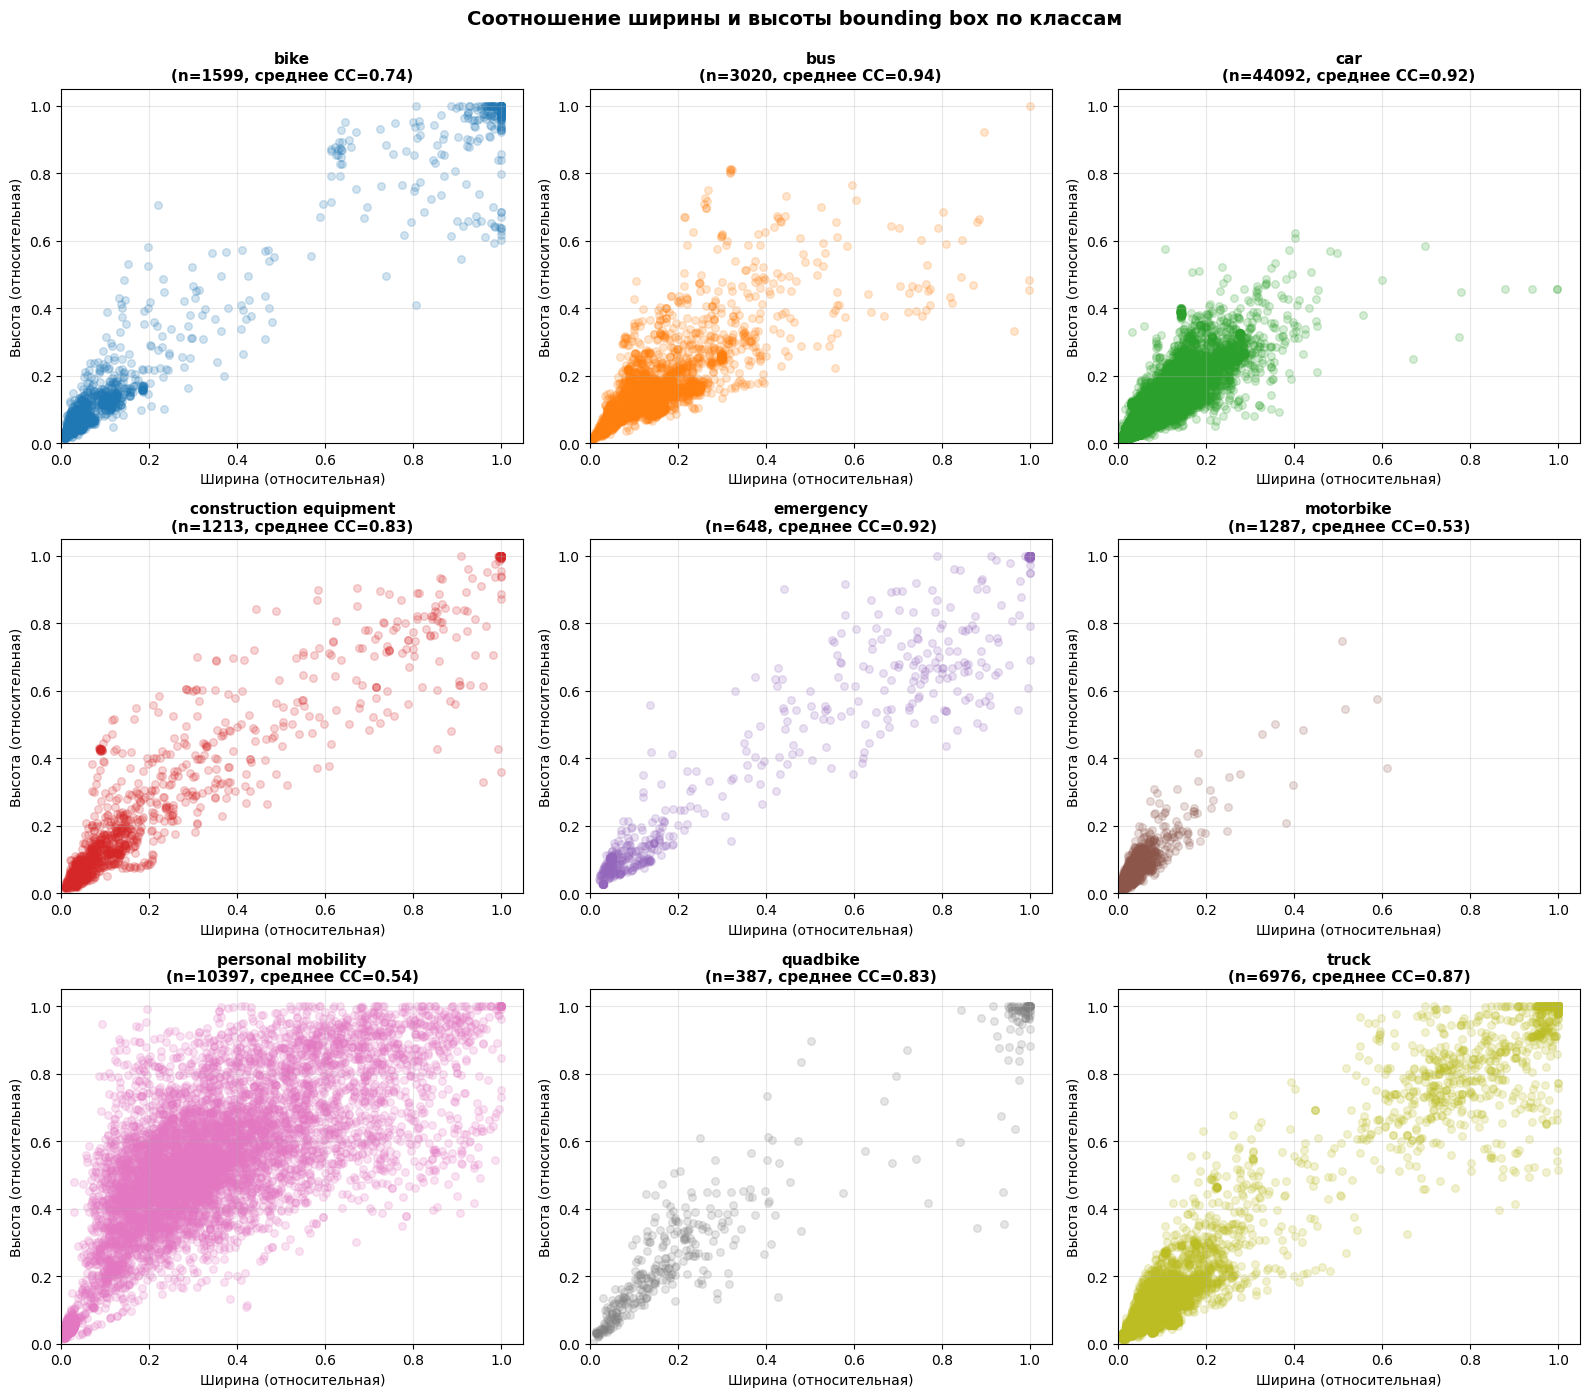

In [74]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for idx, cls_id in enumerate(sorted(df_bbox['class'].unique())):
    cls_data = df_bbox[df_bbox['class'] == cls_id]
    cls_name_str = class_name[cls_id]
    
    ax = axes[idx]
    ax.scatter(cls_data['w_rel'], cls_data['h_rel'], alpha=0.2, s=30, color=f'C{idx}')
    ax.set_xlabel("Ширина (относительная)", fontsize=10)
    ax.set_ylabel("Высота (относительная)", fontsize=10)
    ax.set_title(f"{cls_name_str}\n(n={len(cls_data)}, среднее СС={cls_data['aspect_ratio'].mean():.2f})", fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.set_xlim([0, df_bbox['w_rel'].max() * 1.05])
    ax.set_ylim([0, df_bbox['h_rel'].max() * 1.05])

# Удаляем пустые подграфики
for idx in range(len(df_bbox['class'].unique()), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle("Соотношение ширины и высоты bounding box по классам", fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


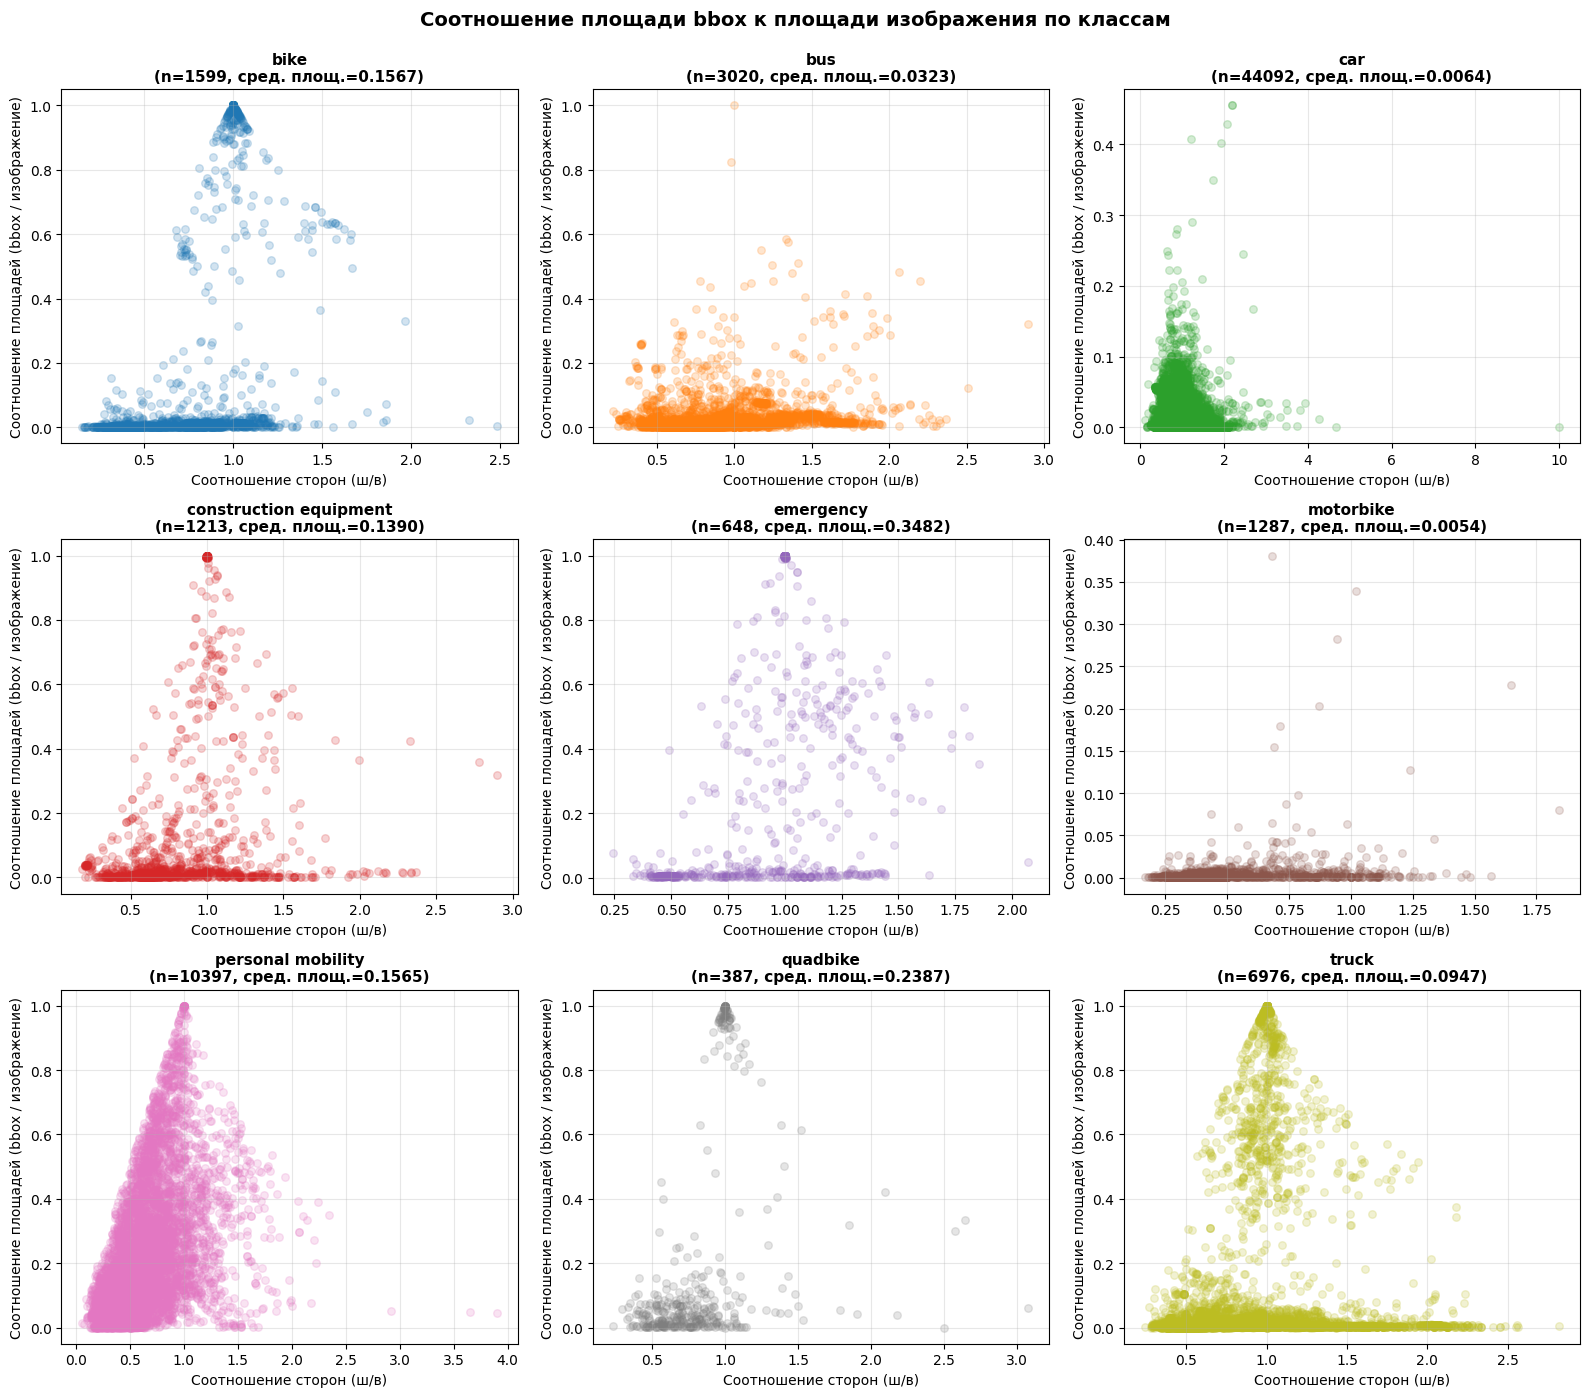

In [75]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for idx, cls_id in enumerate(sorted(df_bbox['class'].unique())):
    cls_data = df_bbox[df_bbox['class'] == cls_id]
    cls_name_str = class_name[cls_id]
    
    ax = axes[idx]
    ax.scatter(cls_data['aspect_ratio'], cls_data['area_rel'], alpha=0.2, s=30, color=f'C{idx}')
    ax.set_xlabel("Соотношение сторон (ш/в)", fontsize=10)
    ax.set_ylabel("Соотношение площадей (bbox / изображение)", fontsize=10)
    ax.set_title(f"{cls_name_str}\n(n={len(cls_data)}, сред. площ.={cls_data['area_rel'].mean():.4f})", fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)

# Удаляем пустые подграфики
for idx in range(len(df_bbox['class'].unique()), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle("Соотношение площади bbox к площади изображения по классам", fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

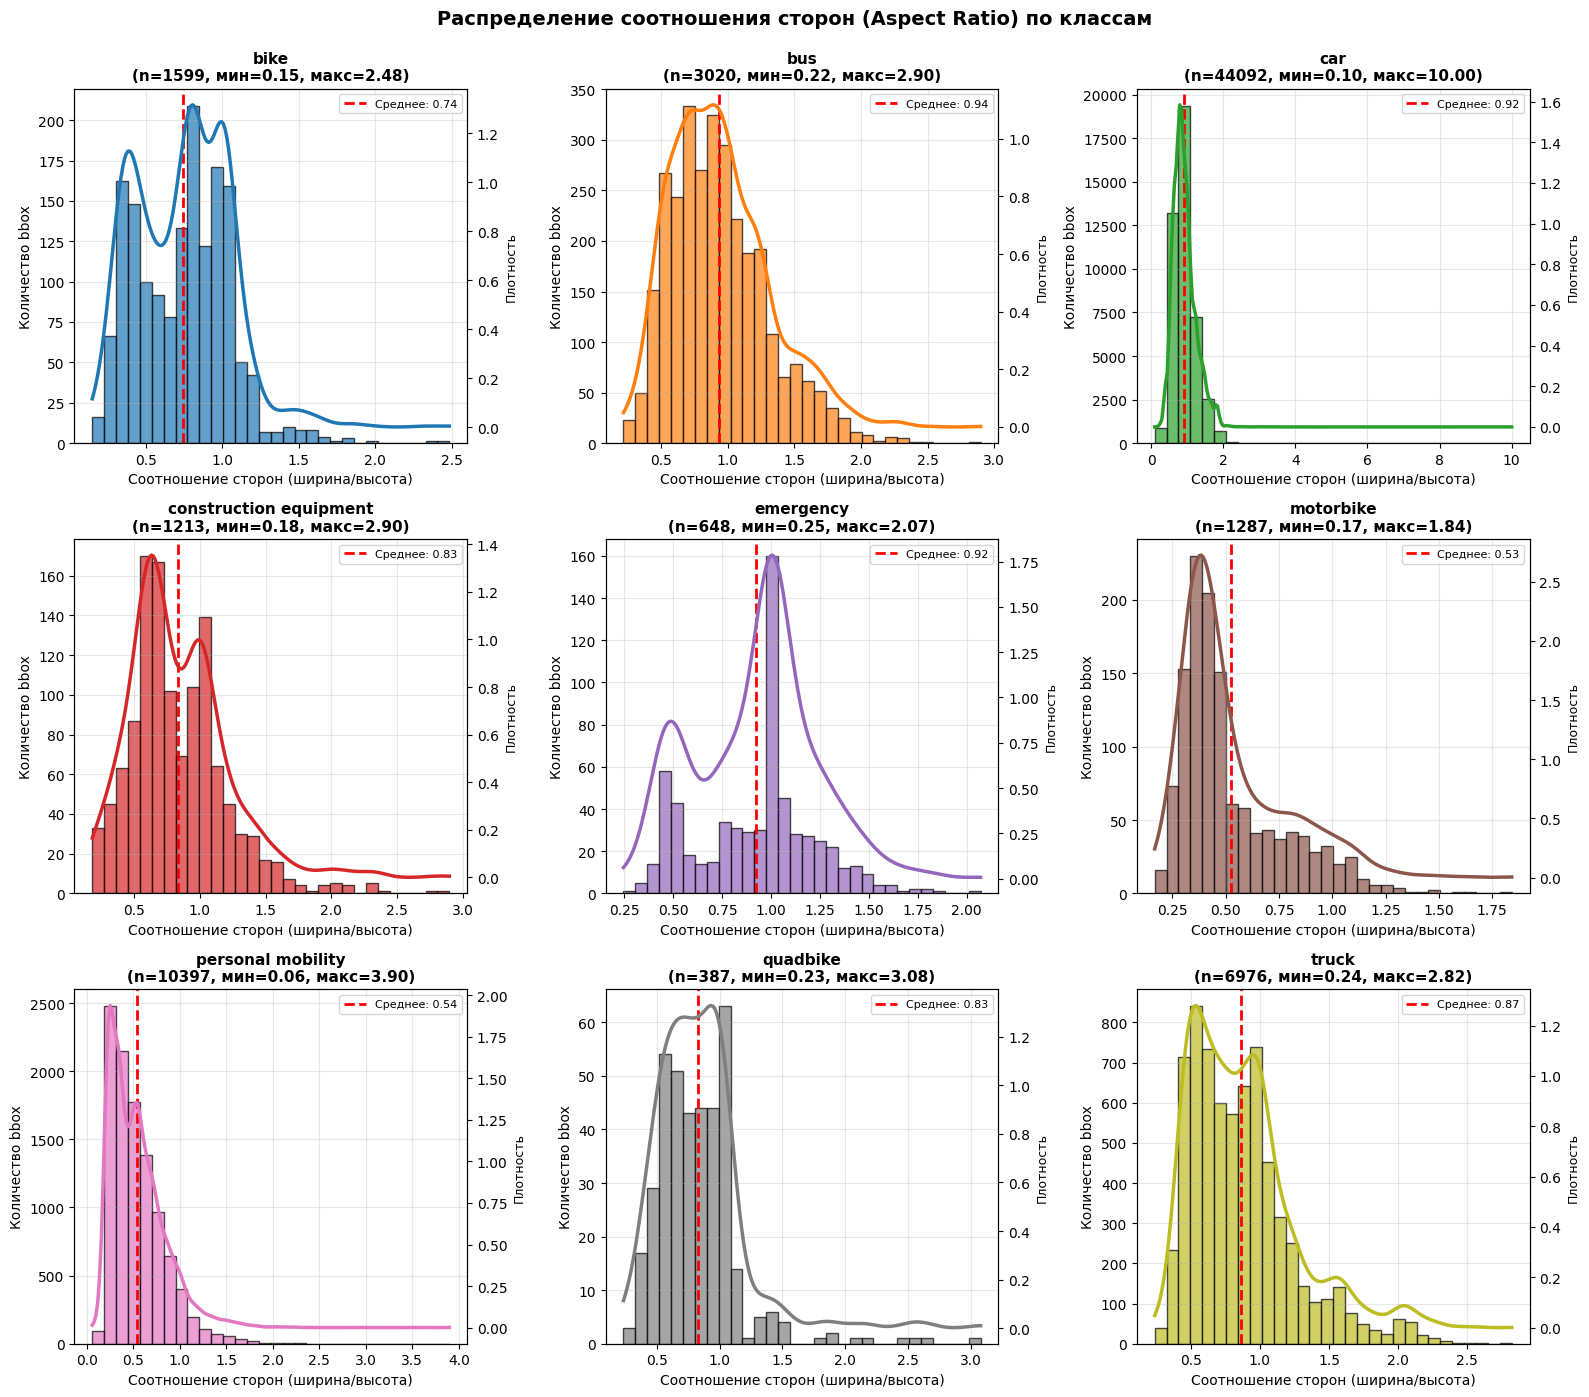

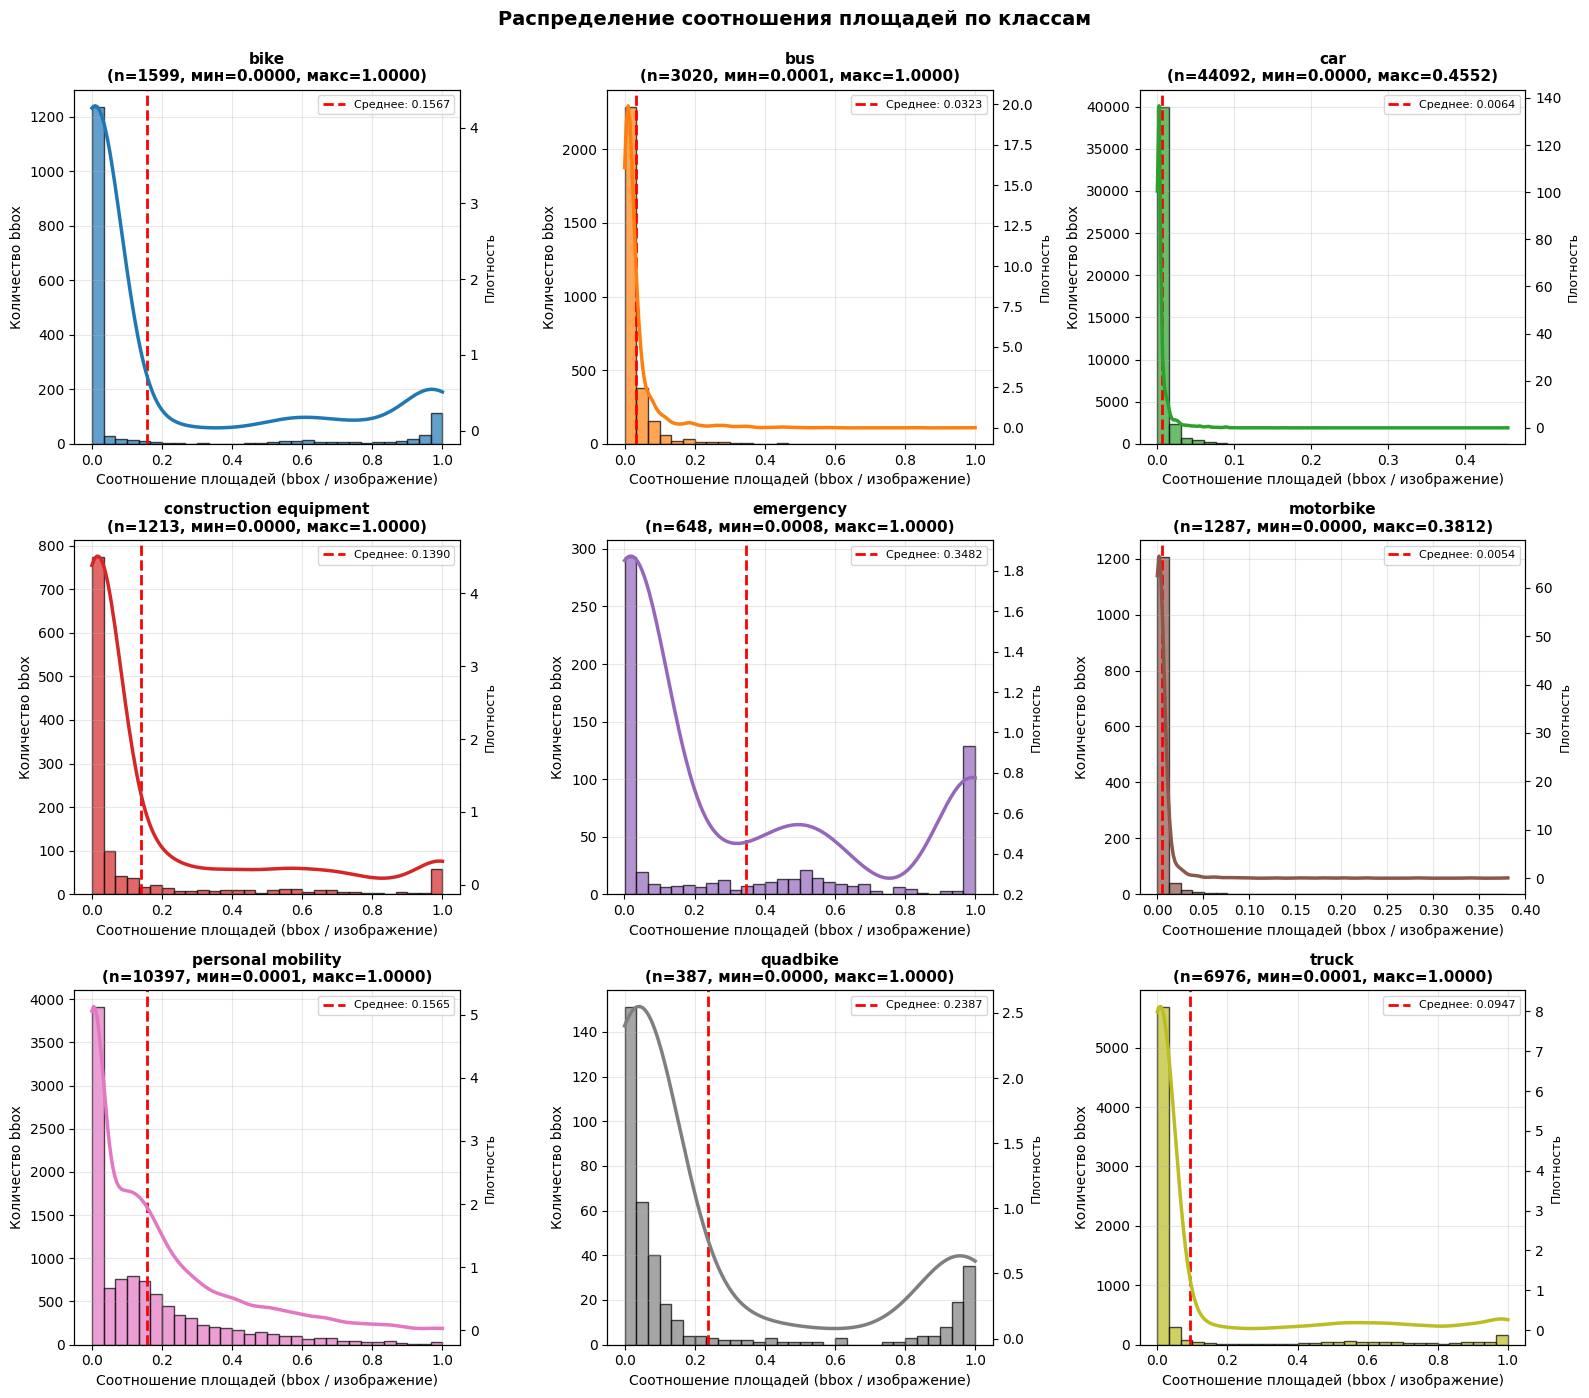

In [76]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for idx, cls_id in enumerate(sorted(df_bbox['class'].unique())):
    cls_data = df_bbox[df_bbox['class'] == cls_id]
    cls_name_str = class_name[cls_id]
    
    ax = axes[idx]
    ax.hist(cls_data['aspect_ratio'], bins=30, color=f'C{idx}', alpha=0.7, edgecolor='black')
    

    if len(cls_data) > 1:
        try:
            kde = gaussian_kde(cls_data['aspect_ratio'])
            x_range = np.linspace(cls_data['aspect_ratio'].min(), 
                                 cls_data['aspect_ratio'].max(), 200)
            ax2 = ax.twinx()
            ax2.plot(x_range, kde(x_range), color=f'C{idx}', linewidth=2.5)
            ax2.set_ylabel('Плотность', fontsize=9)
        except:
            pass
    
    mean_val = cls_data['aspect_ratio'].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_val:.2f}')
    
    ax.set_xlabel("Соотношение сторон (ширина/высота)", fontsize=10)
    ax.set_ylabel("Количество bbox", fontsize=10)
    ax.set_title(f"{cls_name_str}\n(n={len(cls_data)}, мин={cls_data['aspect_ratio'].min():.2f}, макс={cls_data['aspect_ratio'].max():.2f})", 
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='best')
    ax.grid(alpha=0.3)

for idx in range(len(df_bbox['class'].unique()), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle("Распределение соотношения сторон (Aspect Ratio) по классам", fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for idx, cls_id in enumerate(sorted(df_bbox['class'].unique())):
    cls_data = df_bbox[df_bbox['class'] == cls_id]
    cls_name_str = class_name[cls_id]
    
    ax = axes[idx]
    ax.hist(cls_data['area_rel'], bins=30, color=f'C{idx}', alpha=0.7, edgecolor='black')

    if len(cls_data) > 1:
        try:
            kde = gaussian_kde(cls_data['area_rel'])
            x_range = np.linspace(cls_data['area_rel'].min(), 
                                 cls_data['area_rel'].max(), 200)
            ax2 = ax.twinx()
            ax2.plot(x_range, kde(x_range), color=f'C{idx}', linewidth=2.5)
            ax2.set_ylabel('Плотность', fontsize=9)
        except:
            pass
    
    mean_val = cls_data['area_rel'].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_val:.4f}')
    
    ax.set_xlabel("Соотношение площадей (bbox / изображение)", fontsize=10)
    ax.set_ylabel("Количество bbox", fontsize=10)
    ax.set_title(f"{cls_name_str}\n(n={len(cls_data)}, мин={cls_data['area_rel'].min():.4f}, макс={cls_data['area_rel'].max():.4f})", 
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='best')
    ax.grid(alpha=0.3)

for idx in range(len(df_bbox['class'].unique()), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle("Распределение соотношения площадей по классам", fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


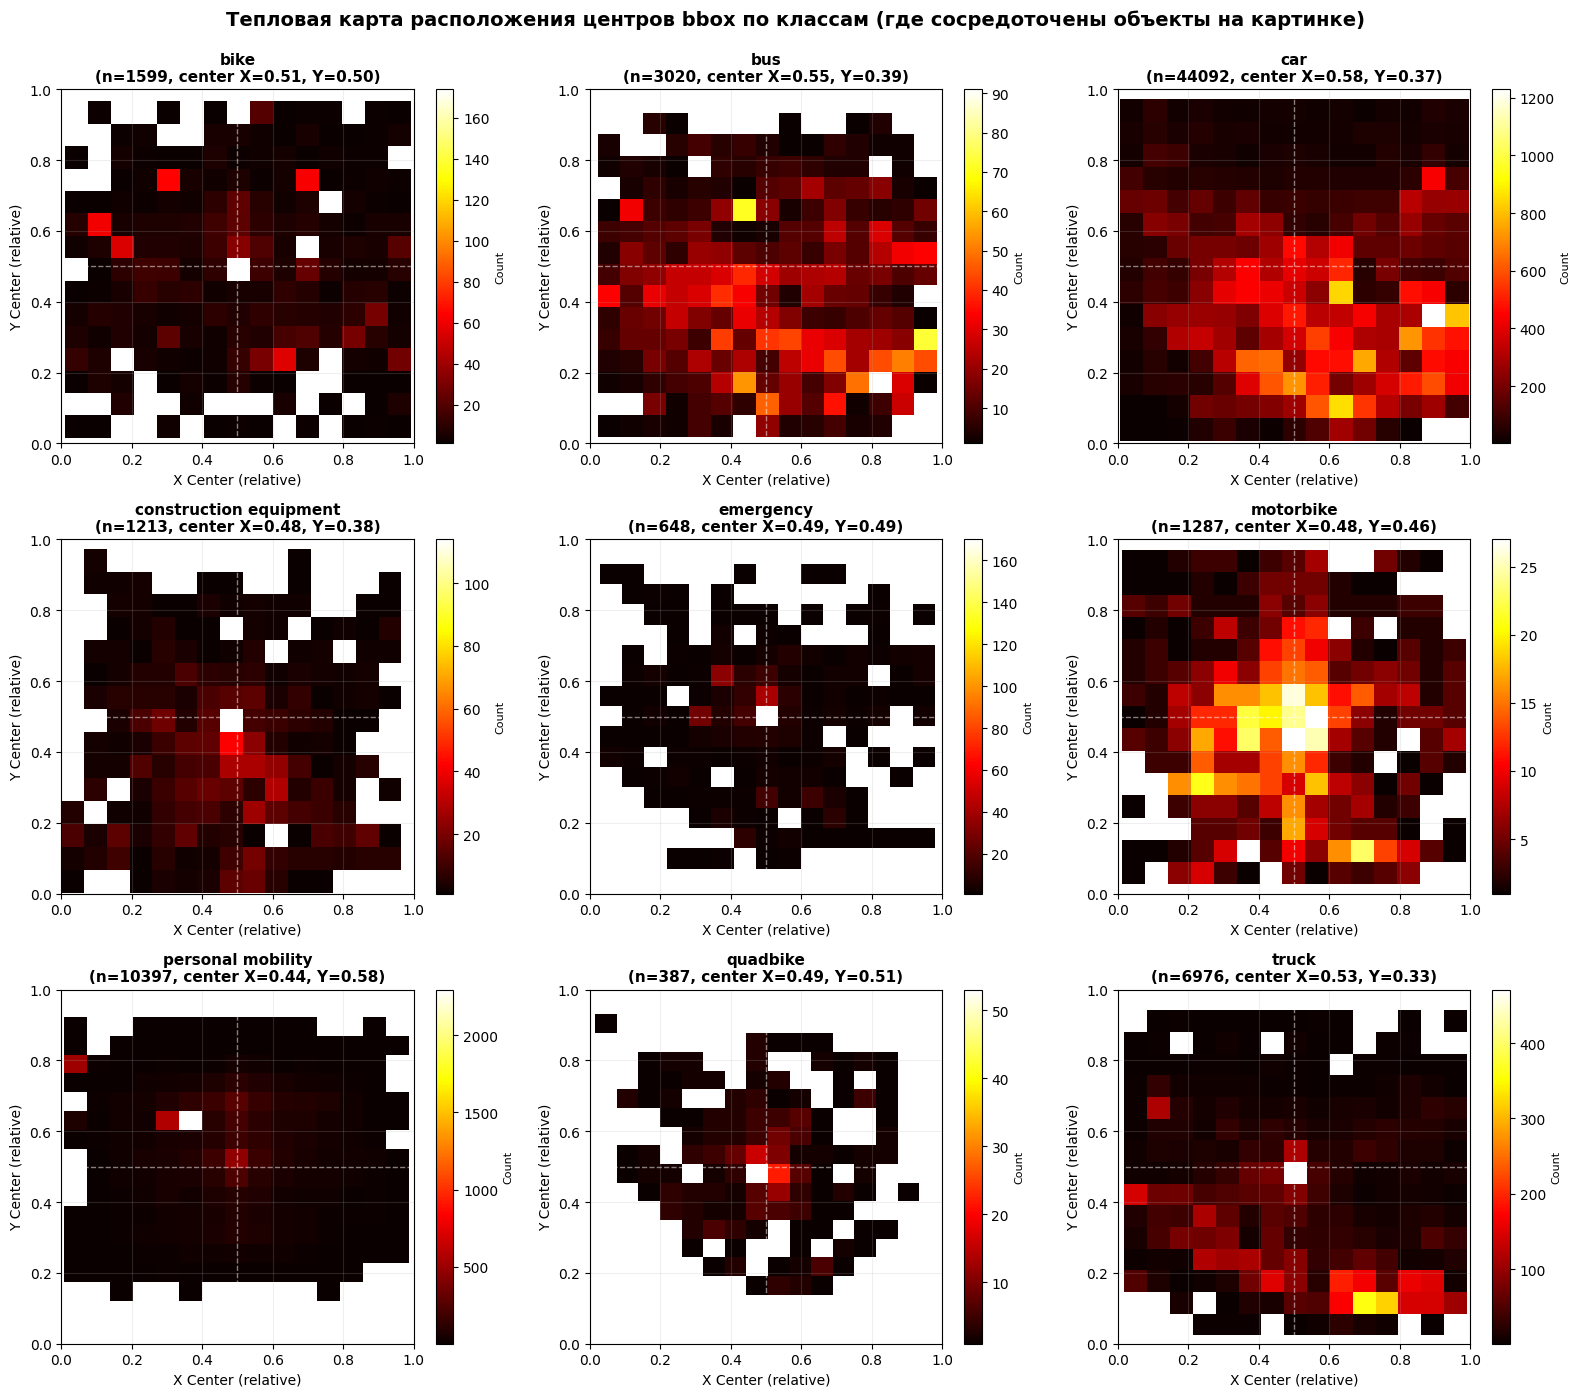

In [77]:
import matplotlib.patches as patches

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for idx, cls_id in enumerate(sorted(df_bbox['class'].unique())):
    cls_data = df_bbox[df_bbox['class'] == cls_id]
    cls_name_str = class_name[cls_id]
    
    ax = axes[idx]
    
    # 2D histogram (heat map) центров объектов
    h = ax.hist2d(cls_data['x_center_rel'], cls_data['y_center_rel'], 
                   bins=15, cmap='hot', cmin=1)
    
    # Добавляем colorbar
    cbar = plt.colorbar(h[3], ax=ax)
    cbar.set_label('Count', fontsize=8)
    
    ax.set_xlabel("X Center (relative)", fontsize=10)
    ax.set_ylabel("Y Center (relative)", fontsize=10)
    ax.set_title(f"{cls_name_str}\n(n={len(cls_data)}, center X={cls_data['x_center_rel'].mean():.2f}, Y={cls_data['y_center_rel'].mean():.2f})", 
                 fontsize=11, fontweight='bold')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.grid(alpha=0.2)
    
    # Добавляем крест в центре изображения
    ax.axhline(0.5, color='white', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(0.5, color='white', linestyle='--', linewidth=1, alpha=0.5)

# Удаляем пустые подграфики
for idx in range(len(df_bbox['class'].unique()), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle("Тепловая карта расположения центров bbox по классам (где сосредоточены объекты на картинке)", 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()



In [78]:
# Вычисляем параметры изображений: яркость, контрастность, насыщенность
from PIL import Image, ImageStat
import colorsys

img_params = []

for img_path in images_path.glob("*"):
    img = Image.open(img_path)
    
    # Конвертируем в RGB если нужно
    if img.mode != 'RGB':
        img = img.convert('RGB')
    
    # Получаем RGB данные
    img_array = np.array(img)
    
    # Яркость (средний уровень яркости) - это просто среднее значение всех пикселей
    brightness = np.mean(img_array)
    
    # Контрастность - используем стандартное отклонение пикселей
    contrast = np.std(img_array)
    
    # Средние значения для каждого канала
    r_mean = np.mean(img_array[:, :, 0])
    g_mean = np.mean(img_array[:, :, 1])
    b_mean = np.mean(img_array[:, :, 2])
    
    # Насыщенность - вычисляем для каждого пикселя и берём среднее
    saturations = []
    for pixel in img_array.reshape(-1, 3):
        r, g, b = pixel / 255.0
        h, s, v = colorsys.rgb_to_hsv(r, g, b)
        saturations.append(s)
    saturation = np.mean(saturations)
    
    img_params.append({
        "image": img_path.name,
        "brightness": brightness,
        "contrast": contrast,
        "saturation": saturation,
        "r_mean": r_mean,
        "g_mean": g_mean,
        "b_mean": b_mean
    })

df_img_params = pd.DataFrame(img_params)
print("Параметры изображений вычислены!")
df_img_params.head()

Параметры изображений вычислены!


,image,brightness,contrast,saturation,r_mean,g_mean,b_mean
0,-1-_jpg.rf.73cda585ea0ec05ad35eb72f1582638c.jpg,119.234023,62.842727,0.271998,129.694424,117.800898,110.206746
1,-1-_jpg.rf.84ccc89e259f98afafa4b992d4fa09be.jpg,126.541935,67.084482,0.116697,129.841694,125.555127,124.228984
2,-1-_jpg.rf.c56621cbbd864d2d6846dd4106449895.jpg,138.577574,58.460709,0.106717,140.455212,139.610222,135.667288
3,-1-_png_jpg.rf.3cbc430fb8cfac721d47a98f6ce7581...,120.435991,84.687773,0.280914,116.936270,114.794836,129.576868
4,-1-_png_jpg.rf.a1eb93b4c682afe541a236312b86674...,112.453177,83.577136,0.256978,108.523054,108.166626,120.669851


In [86]:
# Общая статистика по параметрам изображений
print("\nЯРКОСТЬ (Brightness):")
print(df_img_params["brightness"].describe())
print("\nКОНТРАСТНОСТЬ (Contrast):")
print(df_img_params["contrast"].describe())
print("\nНАСЫЩЕННОСТЬ (Saturation):")
print(df_img_params["saturation"].describe())
print("\nСредние значения РГБ каналов:")
print(f"  R: {df_img_params['r_mean'].mean():.2f} ± {df_img_params['r_mean'].std():.2f}")
print(f"  G: {df_img_params['g_mean'].mean():.2f} ± {df_img_params['g_mean'].std():.2f}")
print(f"  B: {df_img_params['b_mean'].mean():.2f} ± {df_img_params['b_mean'].std():.2f}")


ЯРКОСТЬ (Brightness):
count    15392.000000
mean       117.002996
std         27.303533
min         16.748054
25%        104.063806
50%        115.205704
75%        126.372092
max        246.450527
Name: brightness, dtype: float64

КОНТРАСТНОСТЬ (Contrast):
count    15392.000000
mean        53.691939
std         14.518211
min         16.041901
25%         43.856364
50%         53.403899
75%         66.038517
max         97.770867
Name: contrast, dtype: float64

НАСЫЩЕННОСТЬ (Saturation):
count    15392.000000
mean         0.172947
std          0.102052
min          0.000000
25%          0.106236
50%          0.152260
75%          0.210483
max          0.943343
Name: saturation, dtype: float64

Средние значения РГБ каналов:
  R: 118.24 ± 27.48
  G: 117.87 ± 27.78
  B: 114.90 ± 28.71


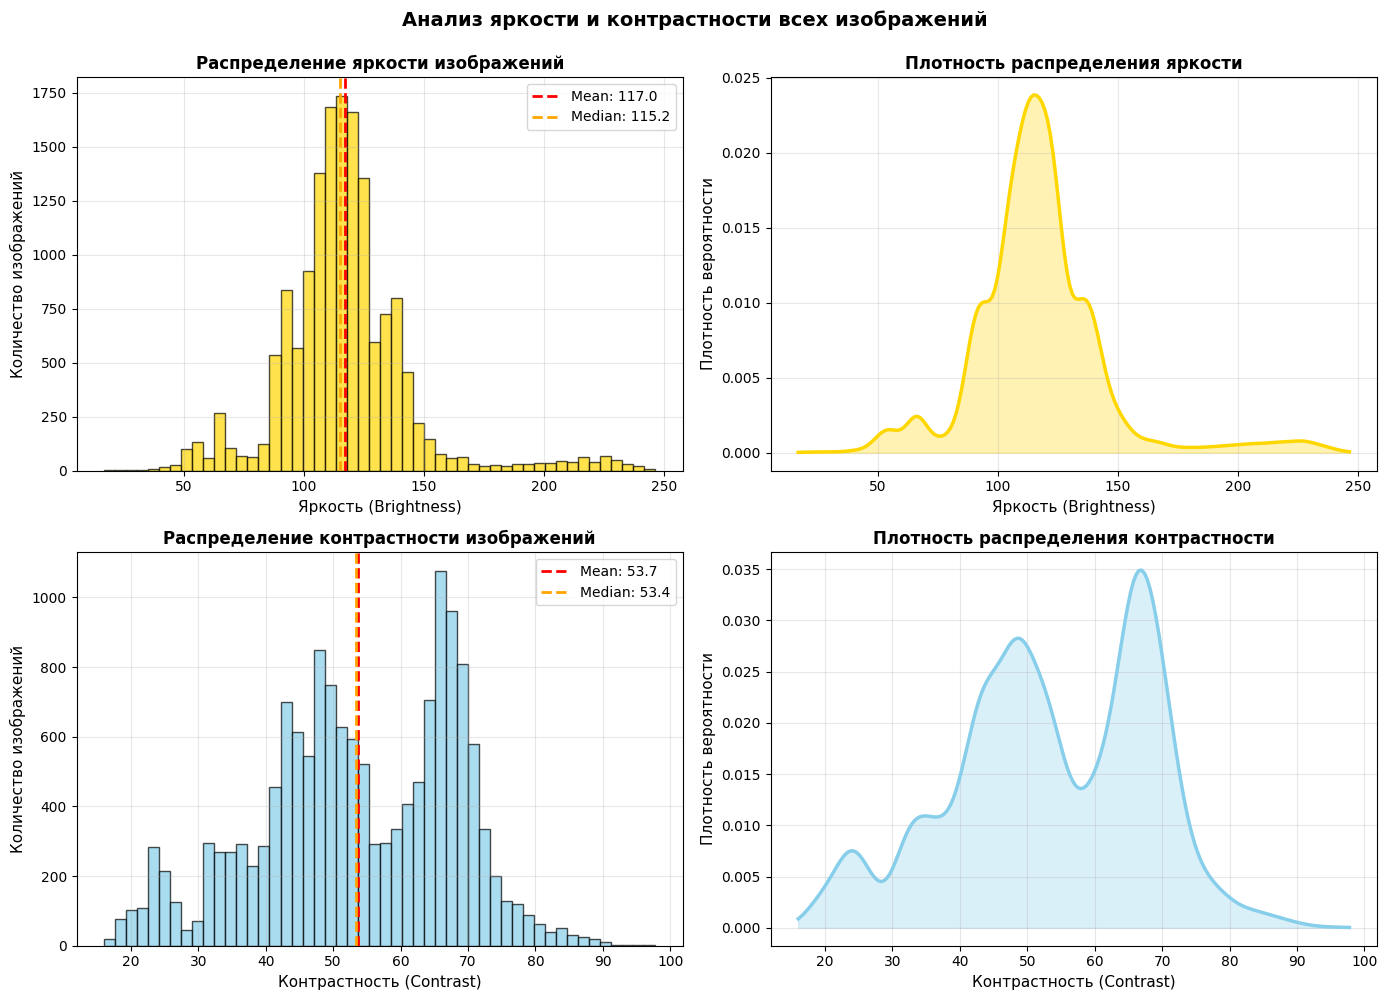

In [80]:
# Распределение яркости и контрастности
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Яркость - гистограмма
ax = axes[0, 0]
ax.hist(df_img_params["brightness"], bins=50, color='gold', edgecolor='black', alpha=0.7)
ax.axvline(df_img_params["brightness"].mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {df_img_params["brightness"].mean():.1f}')
ax.axvline(df_img_params["brightness"].median(), color='orange', linestyle='--', linewidth=2,
           label=f'Median: {df_img_params["brightness"].median():.1f}')
ax.set_xlabel("Яркость (Brightness)", fontsize=11)
ax.set_ylabel("Количество изображений", fontsize=11)
ax.set_title("Распределение яркости изображений", fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Яркость - KDE
ax = axes[0, 1]
from scipy.stats import gaussian_kde
kde_brightness = gaussian_kde(df_img_params["brightness"])
x_brightness = np.linspace(df_img_params["brightness"].min(), df_img_params["brightness"].max(), 200)
ax.plot(x_brightness, kde_brightness(x_brightness), linewidth=2.5, color='gold')
ax.fill_between(x_brightness, kde_brightness(x_brightness), alpha=0.3, color='gold')
ax.set_xlabel("Яркость (Brightness)", fontsize=11)
ax.set_ylabel("Плотность вероятности", fontsize=11)
ax.set_title("Плотность распределения яркости", fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Контрастность - гистограмма
ax = axes[1, 0]
ax.hist(df_img_params["contrast"], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax.axvline(df_img_params["contrast"].mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {df_img_params["contrast"].mean():.1f}')
ax.axvline(df_img_params["contrast"].median(), color='orange', linestyle='--', linewidth=2,
           label=f'Median: {df_img_params["contrast"].median():.1f}')
ax.set_xlabel("Контрастность (Contrast)", fontsize=11)
ax.set_ylabel("Количество изображений", fontsize=11)
ax.set_title("Распределение контрастности изображений", fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Контрастность - KDE
ax = axes[1, 1]
kde_contrast = gaussian_kde(df_img_params["contrast"])
x_contrast = np.linspace(df_img_params["contrast"].min(), df_img_params["contrast"].max(), 200)
ax.plot(x_contrast, kde_contrast(x_contrast), linewidth=2.5, color='skyblue')
ax.fill_between(x_contrast, kde_contrast(x_contrast), alpha=0.3, color='skyblue')
ax.set_xlabel("Контрастность (Contrast)", fontsize=11)
ax.set_ylabel("Плотность вероятности", fontsize=11)
ax.set_title("Плотность распределения контрастности", fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.suptitle("Анализ яркости и контрастности всех изображений", fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

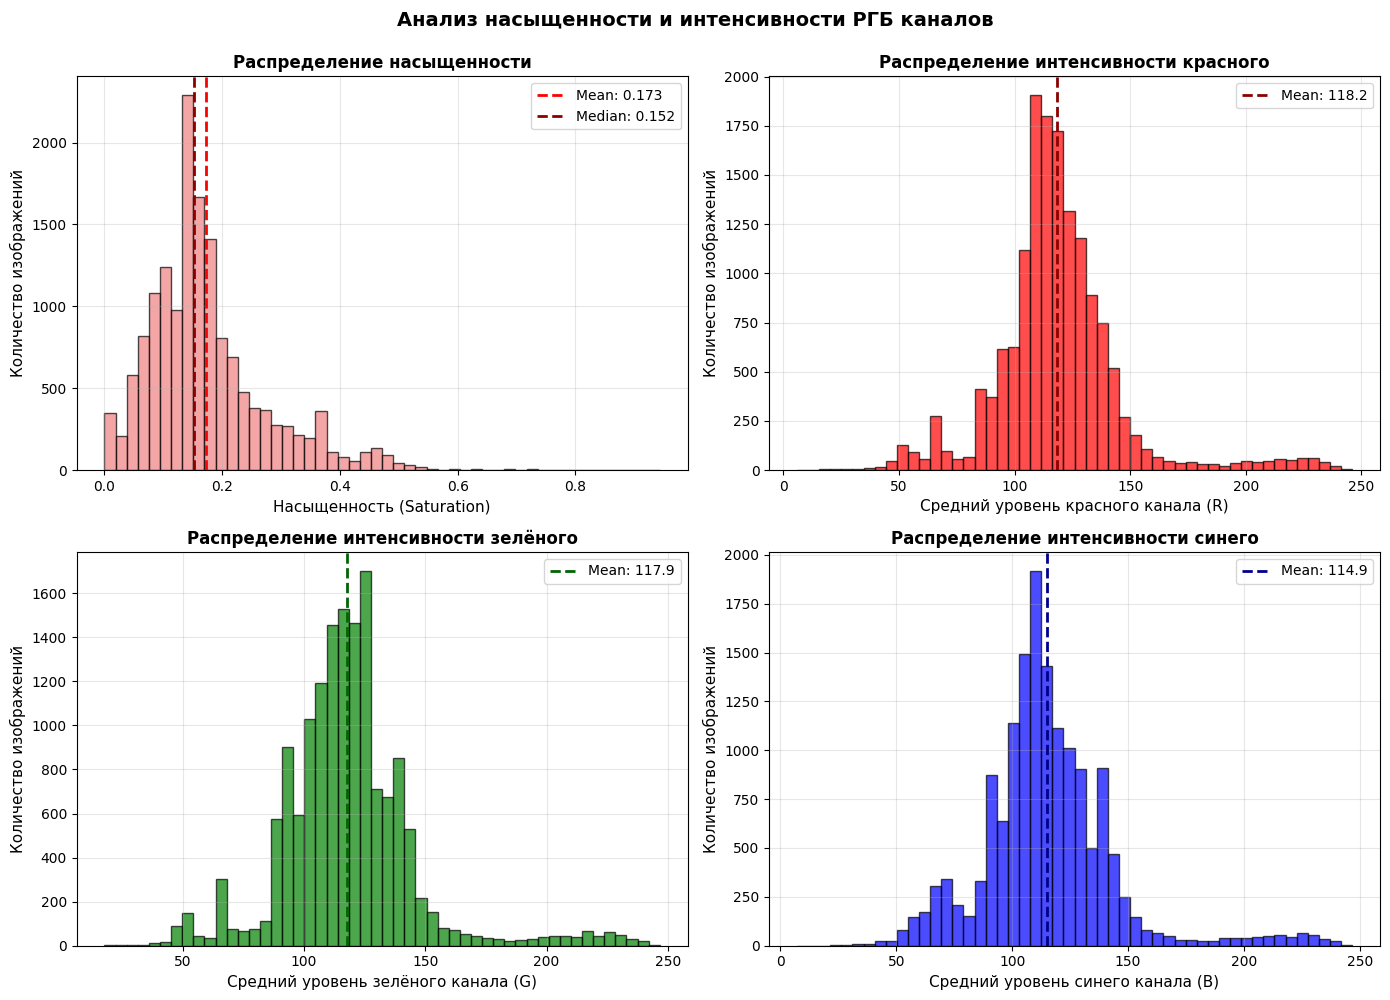

In [81]:
# Распределение насыщенности и средних значений РГБ
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Насыщенность
ax = axes[0, 0]
ax.hist(df_img_params["saturation"], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
ax.axvline(df_img_params["saturation"].mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {df_img_params["saturation"].mean():.3f}')
ax.axvline(df_img_params["saturation"].median(), color='darkred', linestyle='--', linewidth=2,
           label=f'Median: {df_img_params["saturation"].median():.3f}')
ax.set_xlabel("Насыщенность (Saturation)", fontsize=11)
ax.set_ylabel("Количество изображений", fontsize=11)
ax.set_title("Распределение насыщенности", fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Средний уровень красного канала (R)
ax = axes[0, 1]
ax.hist(df_img_params["r_mean"], bins=50, color='red', edgecolor='black', alpha=0.7)
ax.axvline(df_img_params["r_mean"].mean(), color='darkred', linestyle='--', linewidth=2,
           label=f'Mean: {df_img_params["r_mean"].mean():.1f}')
ax.set_xlabel("Средний уровень красного канала (R)", fontsize=11)
ax.set_ylabel("Количество изображений", fontsize=11)
ax.set_title("Распределение интенсивности красного", fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Средний уровень зелёного канала (G)
ax = axes[1, 0]
ax.hist(df_img_params["g_mean"], bins=50, color='green', edgecolor='black', alpha=0.7)
ax.axvline(df_img_params["g_mean"].mean(), color='darkgreen', linestyle='--', linewidth=2,
           label=f'Mean: {df_img_params["g_mean"].mean():.1f}')
ax.set_xlabel("Средний уровень зелёного канала (G)", fontsize=11)
ax.set_ylabel("Количество изображений", fontsize=11)
ax.set_title("Распределение интенсивности зелёного", fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Средний уровень синего канала (B)
ax = axes[1, 1]
ax.hist(df_img_params["b_mean"], bins=50, color='blue', edgecolor='black', alpha=0.7)
ax.axvline(df_img_params["b_mean"].mean(), color='darkblue', linestyle='--', linewidth=2,
           label=f'Mean: {df_img_params["b_mean"].mean():.1f}')
ax.set_xlabel("Средний уровень синего канала (B)", fontsize=11)
ax.set_ylabel("Количество изображений", fontsize=11)
ax.set_title("Распределение интенсивности синего", fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle("Анализ насыщенности и интенсивности РГБ каналов", fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

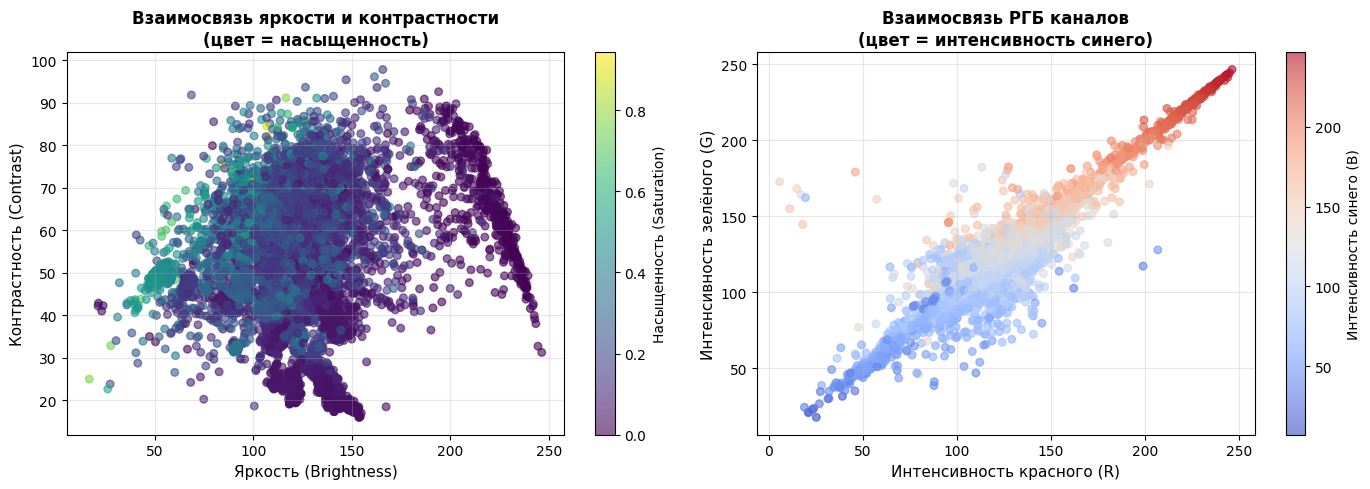

In [82]:
# Scatter plot: взаимосвязь между яркостью и контрастностью, размер точки - насыщенность
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Яркость vs Контрастность
ax = axes[0]
scatter = ax.scatter(df_img_params["brightness"], df_img_params["contrast"], 
                     c=df_img_params["saturation"], s=30, alpha=0.6, cmap='viridis')
ax.set_xlabel("Яркость (Brightness)", fontsize=11)
ax.set_ylabel("Контрастность (Contrast)", fontsize=11)
ax.set_title("Взаимосвязь яркости и контрастности\n(цвет = насыщенность)", fontsize=12, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Насыщенность (Saturation)', fontsize=10)
ax.grid(alpha=0.3)

# RGB каналы
ax = axes[1]
ax.scatter(df_img_params["r_mean"], df_img_params["g_mean"], 
          c=df_img_params["b_mean"], s=30, alpha=0.6, cmap='coolwarm')
ax.set_xlabel("Интенсивность красного (R)", fontsize=11)
ax.set_ylabel("Интенсивность зелёного (G)", fontsize=11)
ax.set_title("Взаимосвязь РГБ каналов\n(цвет = интенсивность синего)", fontsize=12, fontweight='bold')
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Интенсивность синего (B)', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [83]:
# Анализ параметров изображений по классам объектов
# Сначала свяжем параметры изображений с классами
df_img_params_with_classes = df_img_params.copy()

# Для каждого изображения находим какие классы в нём присутствуют
image_classes = []
for img_name in df_img_params["image"]:
    img_stem = img_name.replace(".jpg", "").replace(".png", "")
    label_file = labels_path / (img_stem + ".txt")
    
    classes_in_image = set()
    if label_file.exists():
        with open(label_file) as f:
            for line in f:
                cls_id = int(line.split()[0])
                classes_in_image.add(cls_id)
    
    image_classes.append(list(classes_in_image))

df_img_params_with_classes["classes"] = image_classes

# Создаём развёрнутый датафрейм (для каждого класса в изображении отдельная строка)
expanded_rows = []
for idx, row in df_img_params_with_classes.iterrows():
    for cls_id in row["classes"]:
        expanded_rows.append({
            "brightness": row["brightness"],
            "contrast": row["contrast"],
            "saturation": row["saturation"],
            "r_mean": row["r_mean"],
            "g_mean": row["g_mean"],
            "b_mean": row["b_mean"],
            "class": cls_id
        })

df_img_params_by_class = pd.DataFrame(expanded_rows)

print("Параметры изображений связаны с классами объектов!")
print(f"Всего записей: {len(df_img_params_by_class)}")

Параметры изображений связаны с классами объектов!
Всего записей: 23367


C:\Users\user\AppData\Local\Temp\ipykernel_2544\2421143520.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=['Яркость', 'Контрастность'], patch_artist=True)
C:\Users\user\AppData\Local\Temp\ipykernel_2544\2421143520.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=['Яркость', 'Контрастность'], patch_artist=True)
C:\Users\user\AppData\Local\Temp\ipykernel_2544\2421143520.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=['Яркость', 'Контрастность'], patch_artist=True)
C:\Users\user\AppData\Local\Temp\ipykernel_

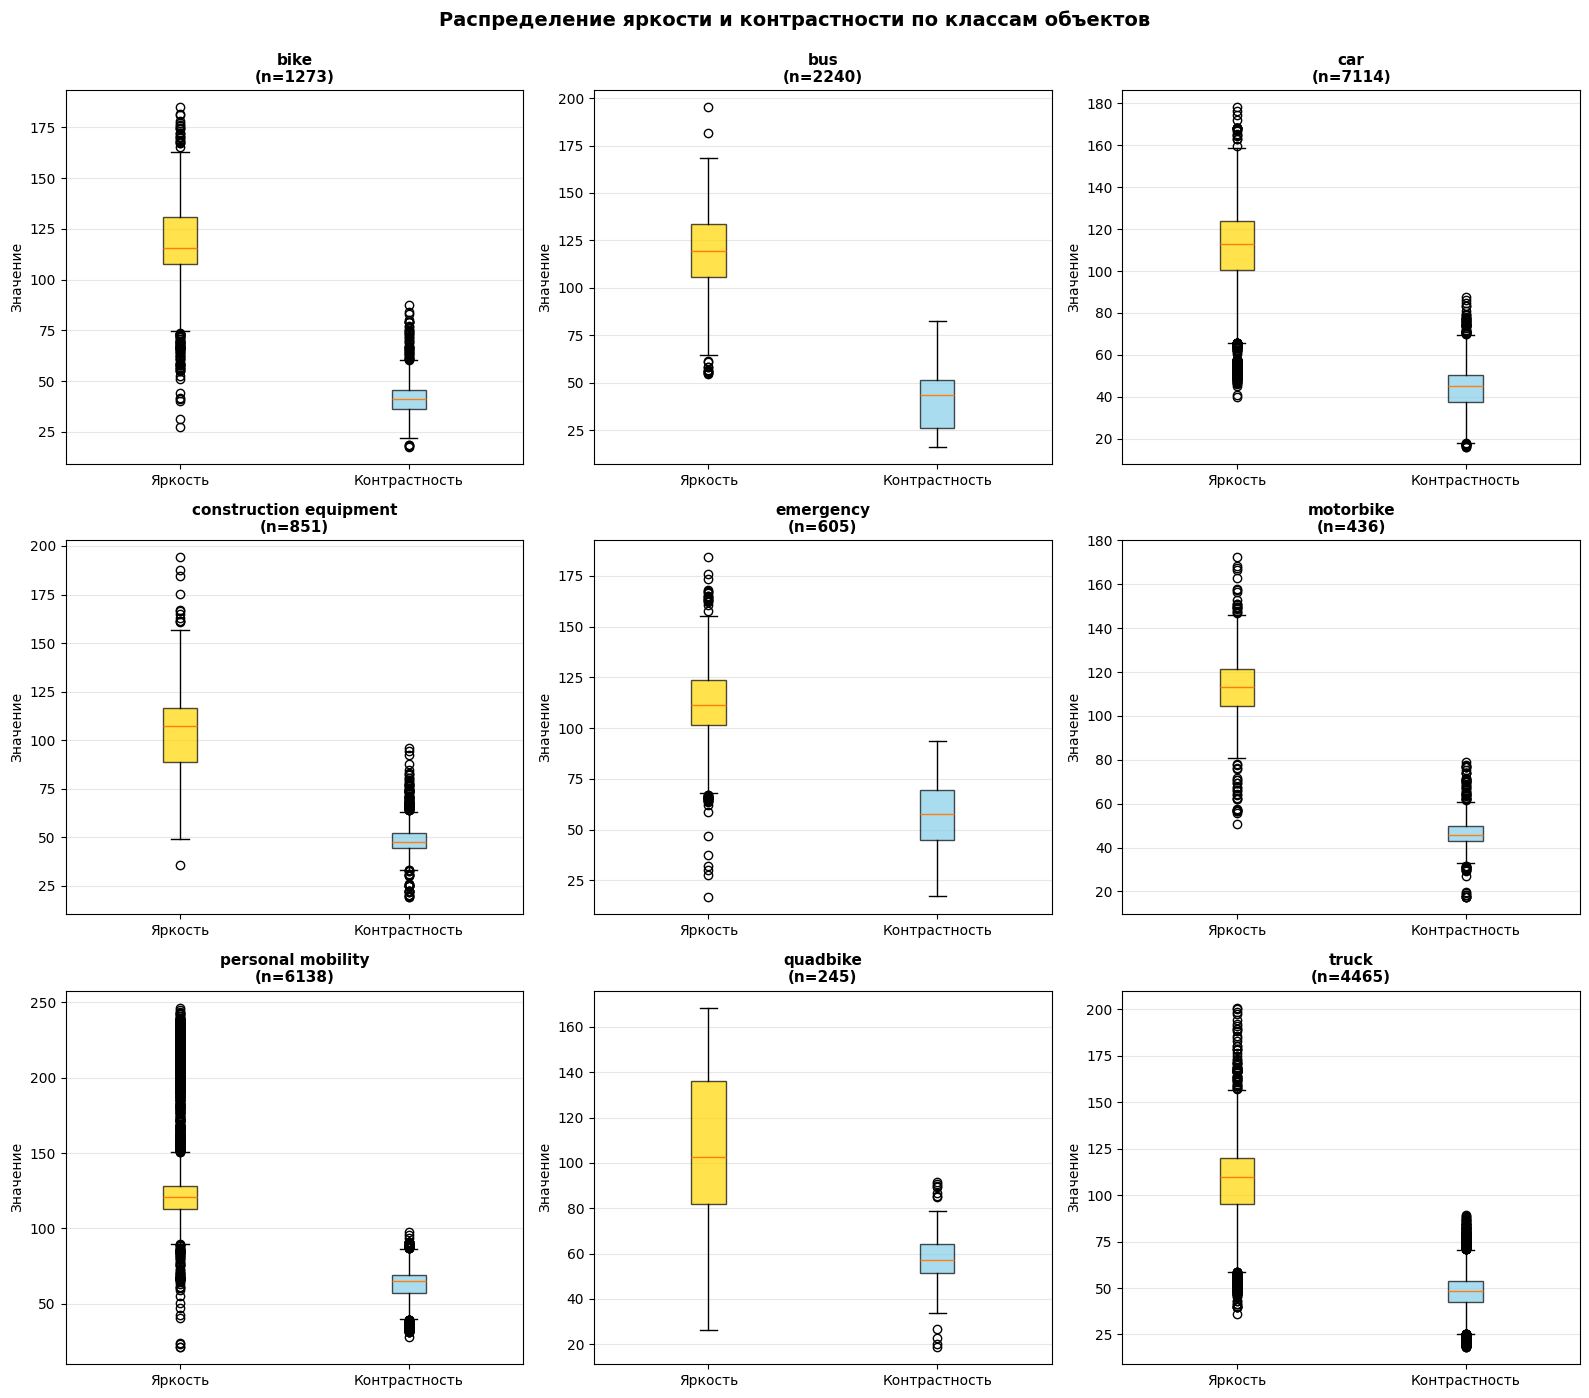

СТАТИСТИКА ПАРАМЕТРОВ ИЗОБРАЖЕНИЙ ПО КЛАССАМ

bike (n=1273):
  Яркость: 116.4 ± 22.7
  Контрастность: 42.3 ± 8.7
  Насыщенность: 0.128 ± 0.069

bus (n=2240):
  Яркость: 118.3 ± 17.9
  Контрастность: 40.6 ± 13.1
  Насыщенность: 0.124 ± 0.062

car (n=7114):
  Яркость: 111.7 ± 21.1
  Контрастность: 43.5 ± 10.6
  Насыщенность: 0.146 ± 0.081

construction equipment (n=851):
  Яркость: 103.0 ± 23.5
  Контрастность: 49.2 ± 10.4
  Насыщенность: 0.215 ± 0.098

emergency (n=605):
  Яркость: 112.3 ± 22.4
  Контрастность: 57.4 ± 15.2
  Насыщенность: 0.190 ± 0.103

motorbike (n=436):
  Яркость: 112.9 ± 20.1
  Контрастность: 47.6 ± 9.8
  Насыщенность: 0.164 ± 0.081

personal mobility (n=6138):
  Яркость: 127.5 ± 29.6
  Контрастность: 63.2 ± 9.4
  Насыщенность: 0.178 ± 0.102

quadbike (n=245):
  Яркость: 105.7 ± 31.4
  Контрастность: 57.4 ± 11.6
  Насыщенность: 0.241 ± 0.140

truck (n=4465):
  Яркость: 108.2 ± 22.5
  Контрастность: 47.8 ± 11.4
  Насыщенность: 0.166 ± 0.102


In [87]:
# Распределение яркости и контрастности по классам
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for idx, cls_id in enumerate(sorted(df_img_params_by_class['class'].unique())):
    cls_data = df_img_params_by_class[df_img_params_by_class['class'] == cls_id]
    cls_name_str = class_name[cls_id]
    
    ax = axes[idx]
    
    # Box plot для яркости (левая часть) и контрастности (правая)
    box_data = [cls_data['brightness'], cls_data['contrast']]
    bp = ax.boxplot(box_data, labels=['Яркость', 'Контрастность'], patch_artist=True)
    
    # Раскрашиваем боксы
    colors = ['gold', 'skyblue']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_ylabel("Значение", fontsize=10)
    ax.set_title(f"{cls_name_str}\n(n={len(cls_data)})", fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')

# Удаляем пустые подграфики
for idx in range(len(df_img_params_by_class['class'].unique()), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle("Распределение яркости и контрастности по классам объектов", 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


print("СТАТИСТИКА ПАРАМЕТРОВ ИЗОБРАЖЕНИЙ ПО КЛАССАМ")


for cls_id in sorted(df_img_params_by_class['class'].unique()):
    cls_data = df_img_params_by_class[df_img_params_by_class['class'] == cls_id]
    cls_name_str = class_name[cls_id]
    
    print(f"\n{cls_name_str} (n={len(cls_data)}):")
    print(f"  Яркость: {cls_data['brightness'].mean():.1f} ± {cls_data['brightness'].std():.1f}")
    print(f"  Контрастность: {cls_data['contrast'].mean():.1f} ± {cls_data['contrast'].std():.1f}")
    print(f"  Насыщенность: {cls_data['saturation'].mean():.3f} ± {cls_data['saturation'].std():.3f}")

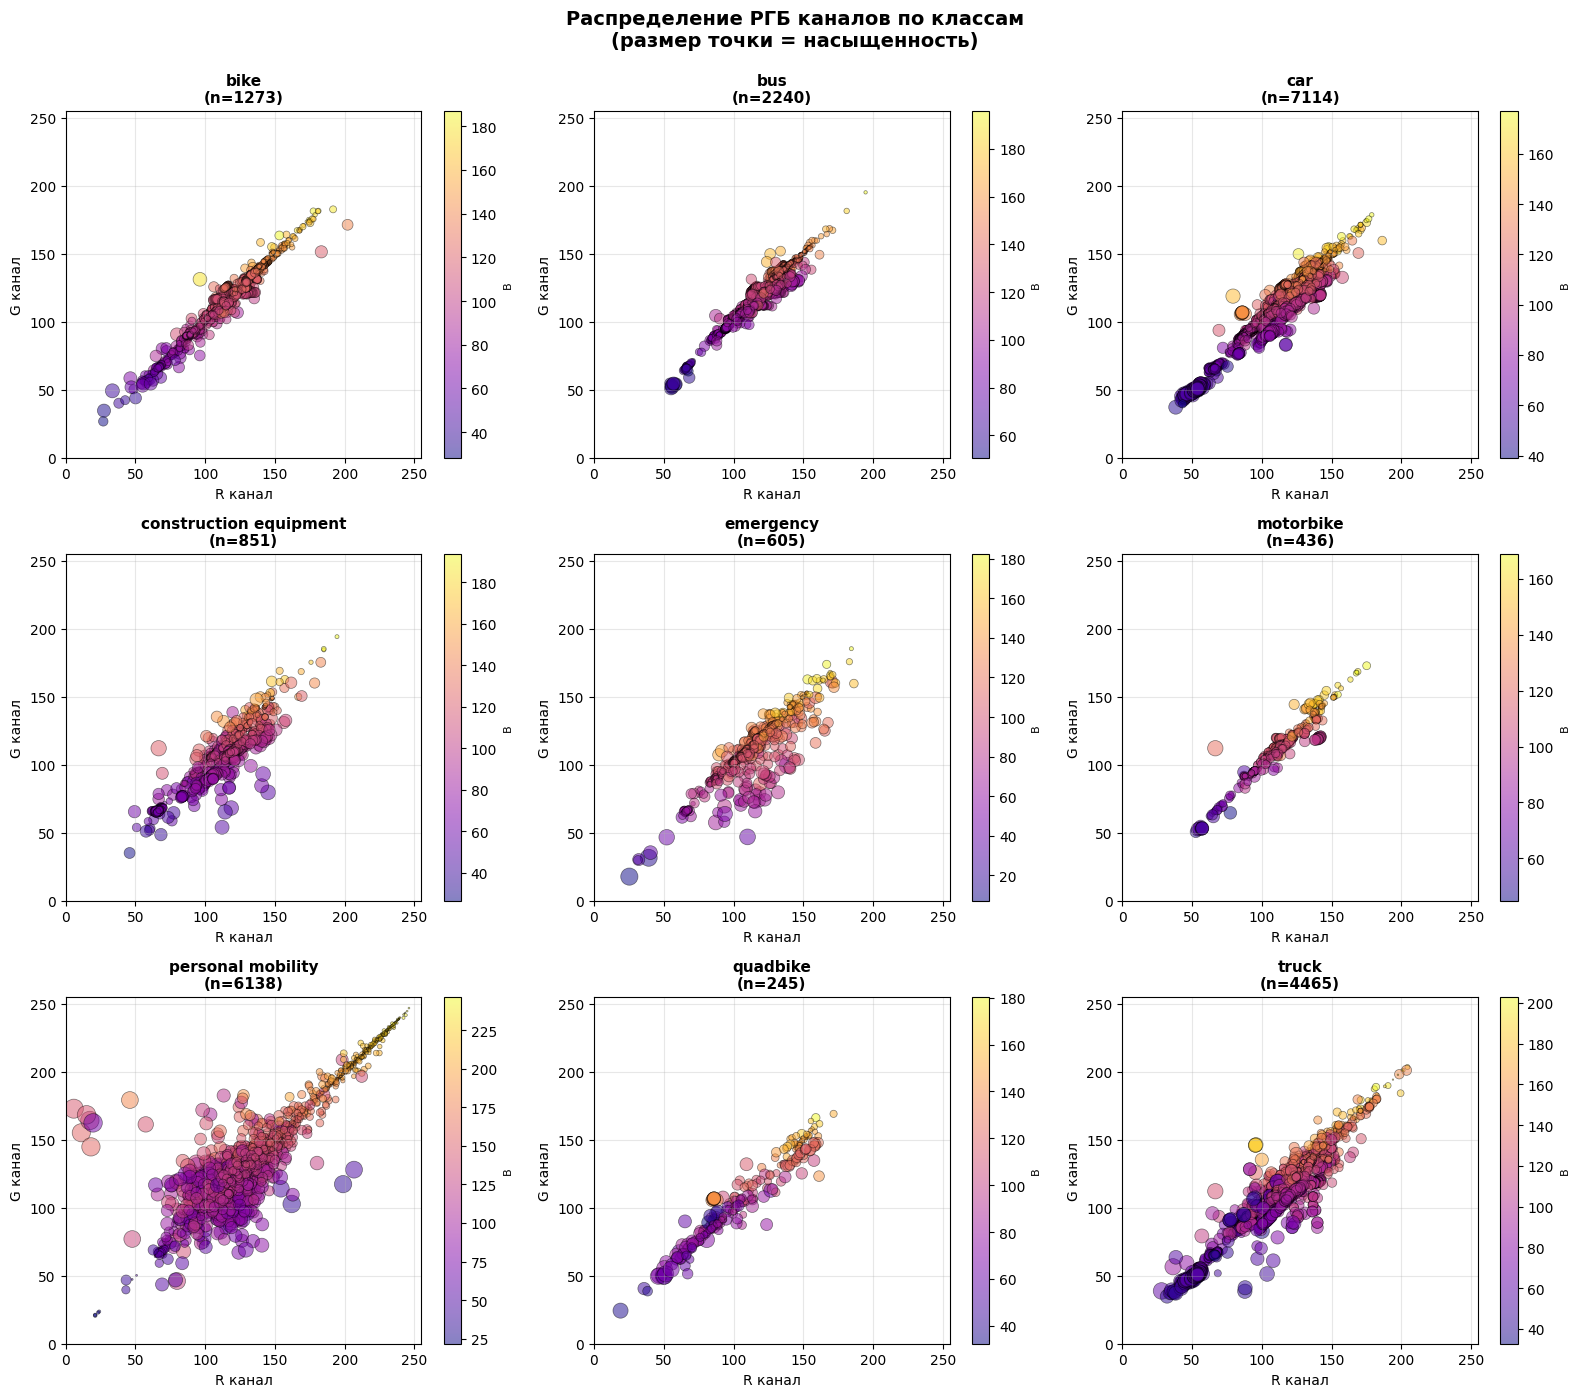

In [88]:
# Распределение насыщенности и средних РГБ по классам
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for idx, cls_id in enumerate(sorted(df_img_params_by_class['class'].unique())):
    cls_data = df_img_params_by_class[df_img_params_by_class['class'] == cls_id]
    cls_name_str = class_name[cls_id]
    
    ax = axes[idx]
    
    # Scatter: R vs G, цвет - B, размер - насыщенность
    scatter = ax.scatter(cls_data['r_mean'], cls_data['g_mean'], 
                        c=cls_data['b_mean'], s=cls_data['saturation']*200, 
                        alpha=0.5, cmap='plasma', edgecolors='black', linewidth=0.5)
    
    ax.set_xlabel("R канал", fontsize=10)
    ax.set_ylabel("G канал", fontsize=10)
    ax.set_title(f"{cls_name_str}\n(n={len(cls_data)})", fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 255])
    ax.set_ylim([0, 255])
    
    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('B', fontsize=8)

# Удаляем пустые подграфики
for idx in range(len(df_img_params_by_class['class'].unique()), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle("Распределение РГБ каналов по классам\n(размер точки = насыщенность)", 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()
